
Gerrit Cole
pitch_type    CH    FC    FF    KC   SI    SL
count                                        
0-0          4.2   9.9  53.1  15.8  0.8  16.2
0-1          9.0   9.7  47.0  15.0  0.5  18.7
0-2          5.5   6.0  44.6  18.4  0.3  25.2
1-0          6.6  14.3  47.5  12.7  1.1  17.7
1-1         11.2  13.1  45.4  14.8  0.2  15.4
1-2          5.6   7.6  43.6  14.7  0.6  27.9
2-0          6.2  16.4  45.2  14.4  2.1  15.8
2-1          6.9  12.0  44.0  15.4  0.8  20.8
2-2          5.4   7.7  51.8  14.3  0.2  20.6
3-0          0.0   4.9  92.7   0.0  2.4   0.0
3-1          4.4   8.8  70.3   7.7  3.3   5.5
3-2          2.0   8.5  68.7   7.1  1.4  12.2

Spencer Strider
pitch_type    CH   CU     FF   PO    SL
count                                  
0-0          2.1  0.5   63.4  0.1  33.9
0-1          9.6  0.6   58.9  0.0  30.9
0-2          7.6  1.1   53.8  0.0  37.5
1-0         10.0  0.0   58.4  0.0  31.5
1-1         15.9  0.6   48.5  0.0  35.0
1-2          8.9  1.1   47.2  0.0  42.9
2-0   

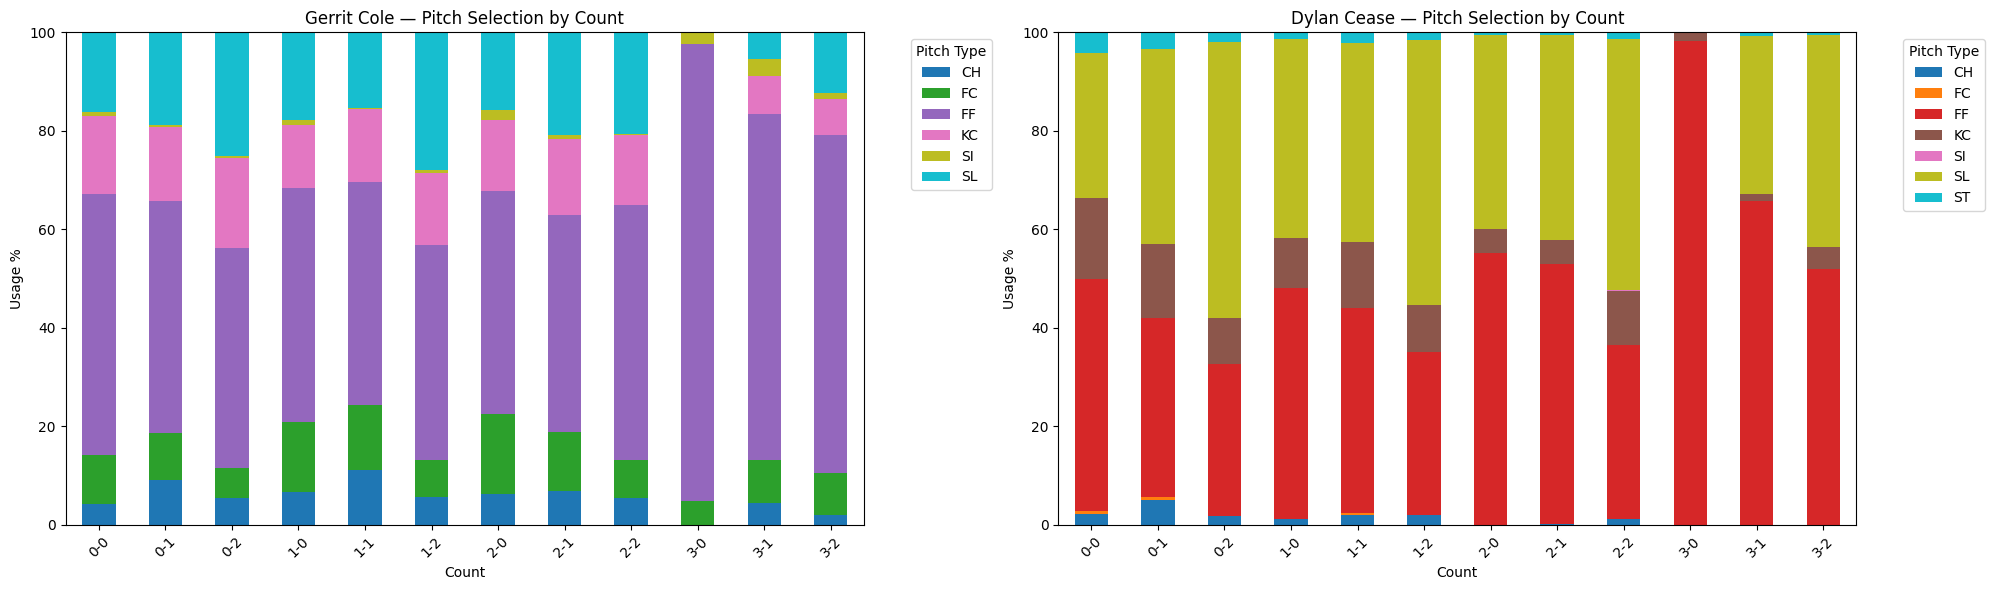

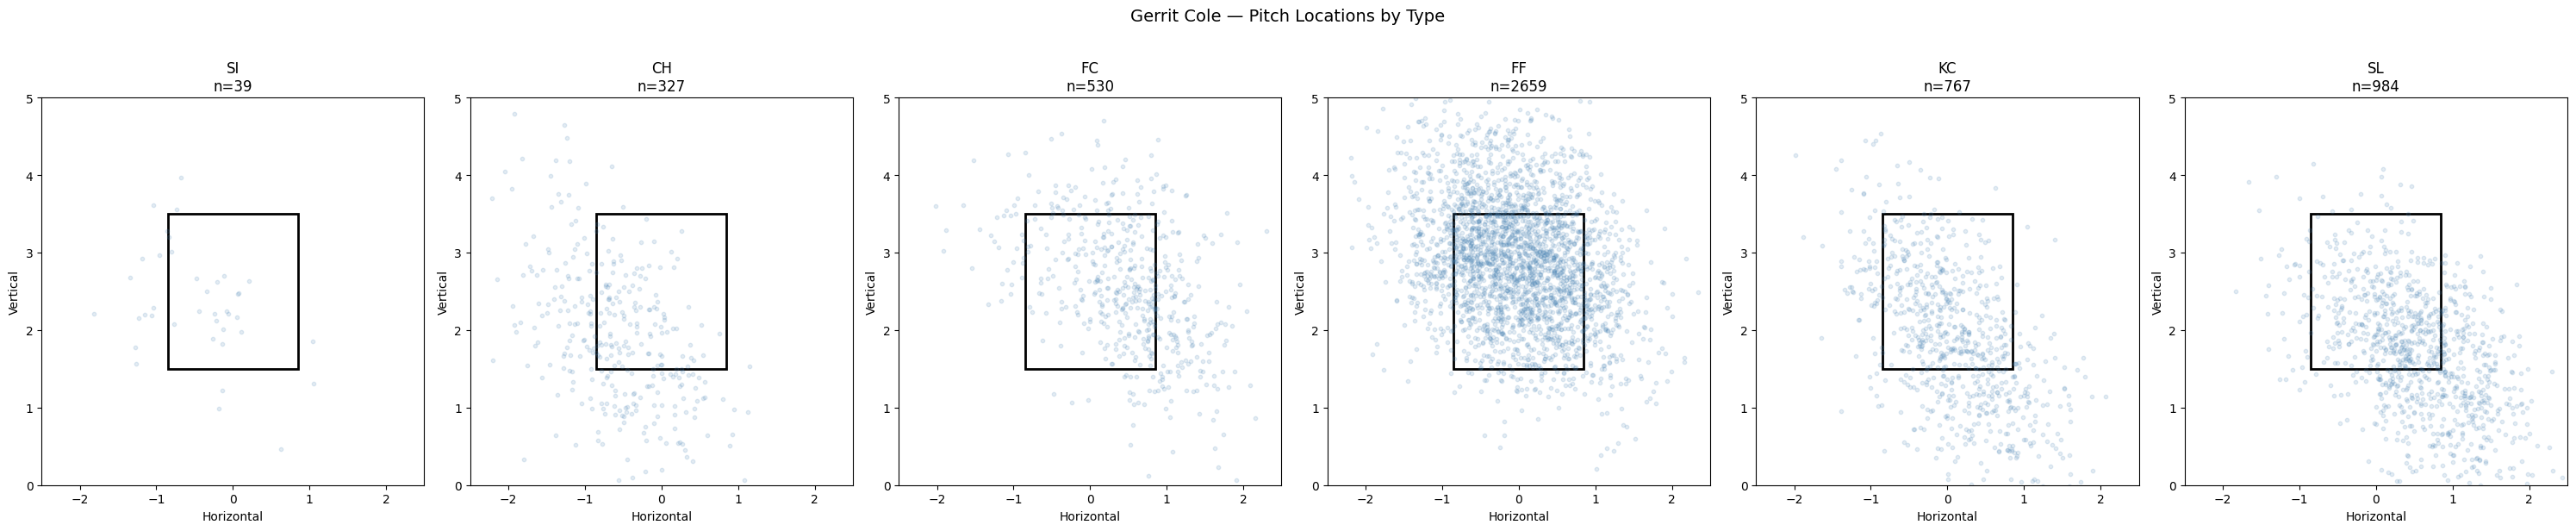

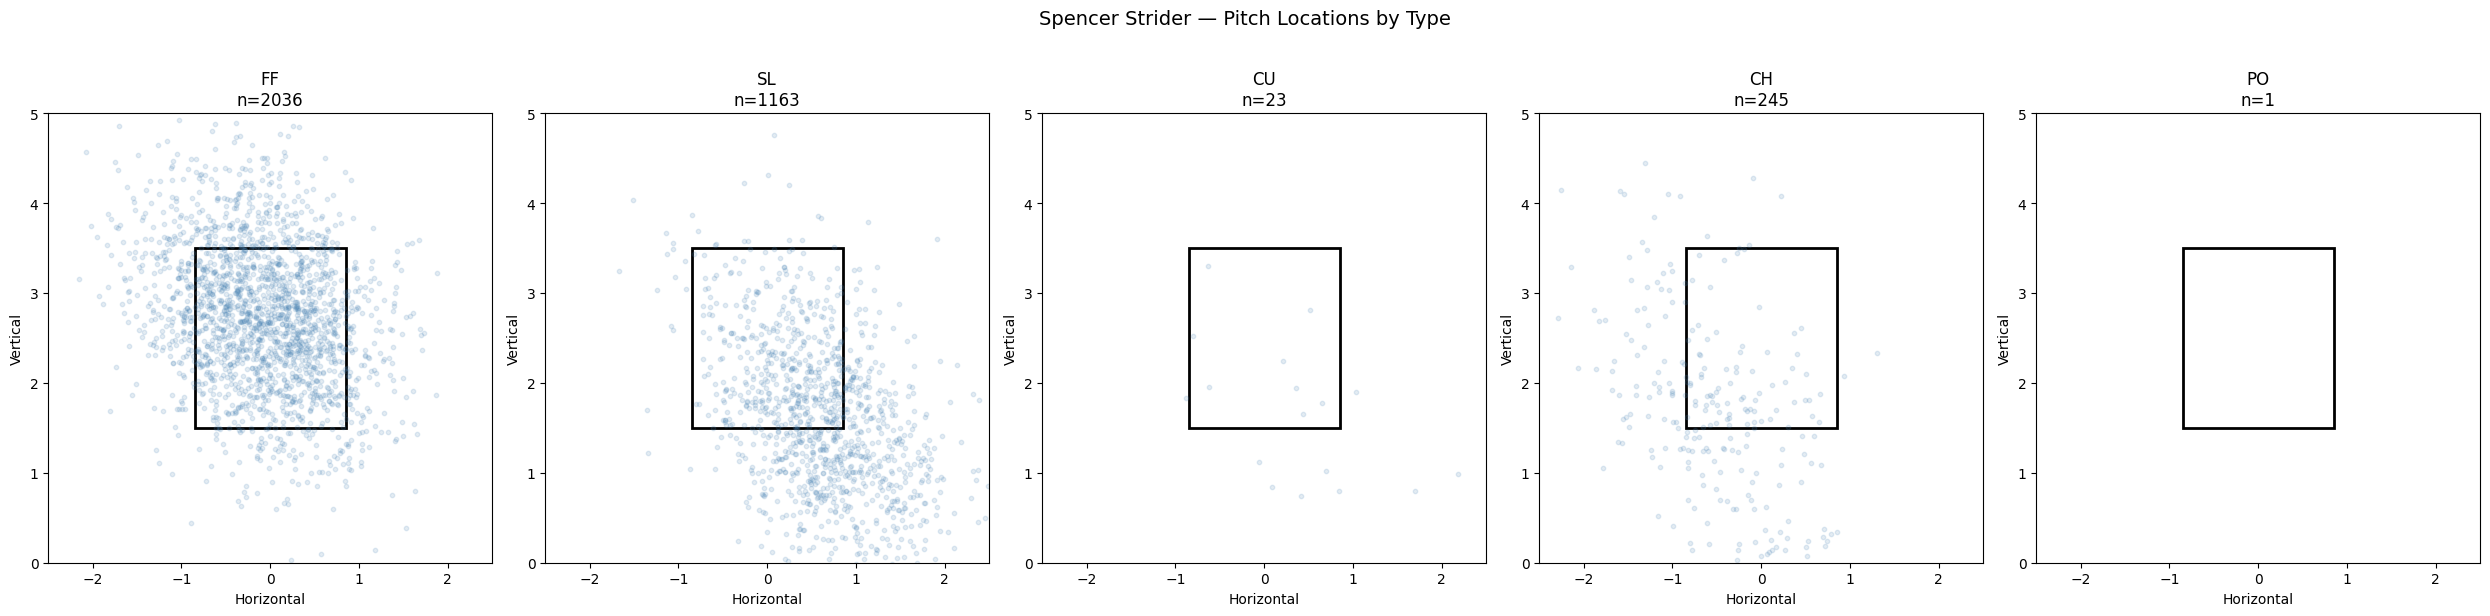

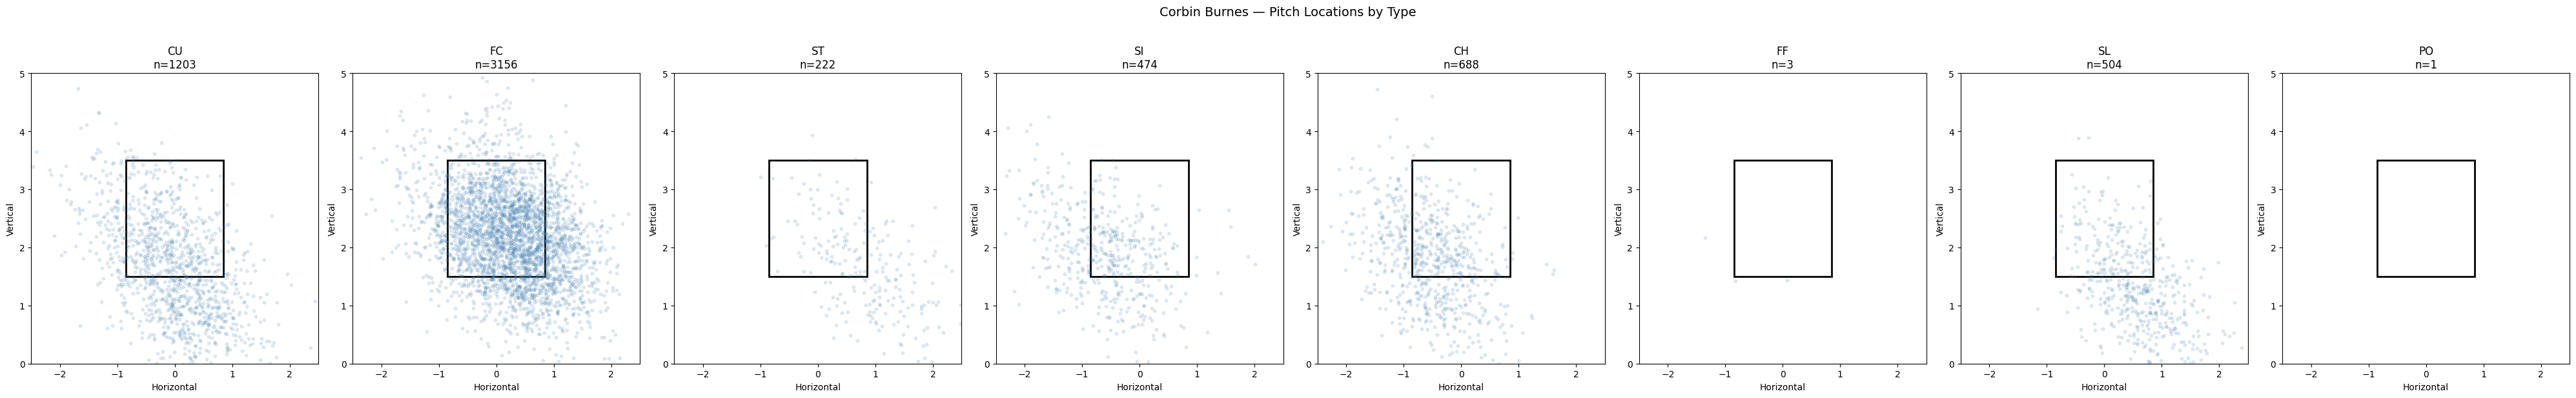

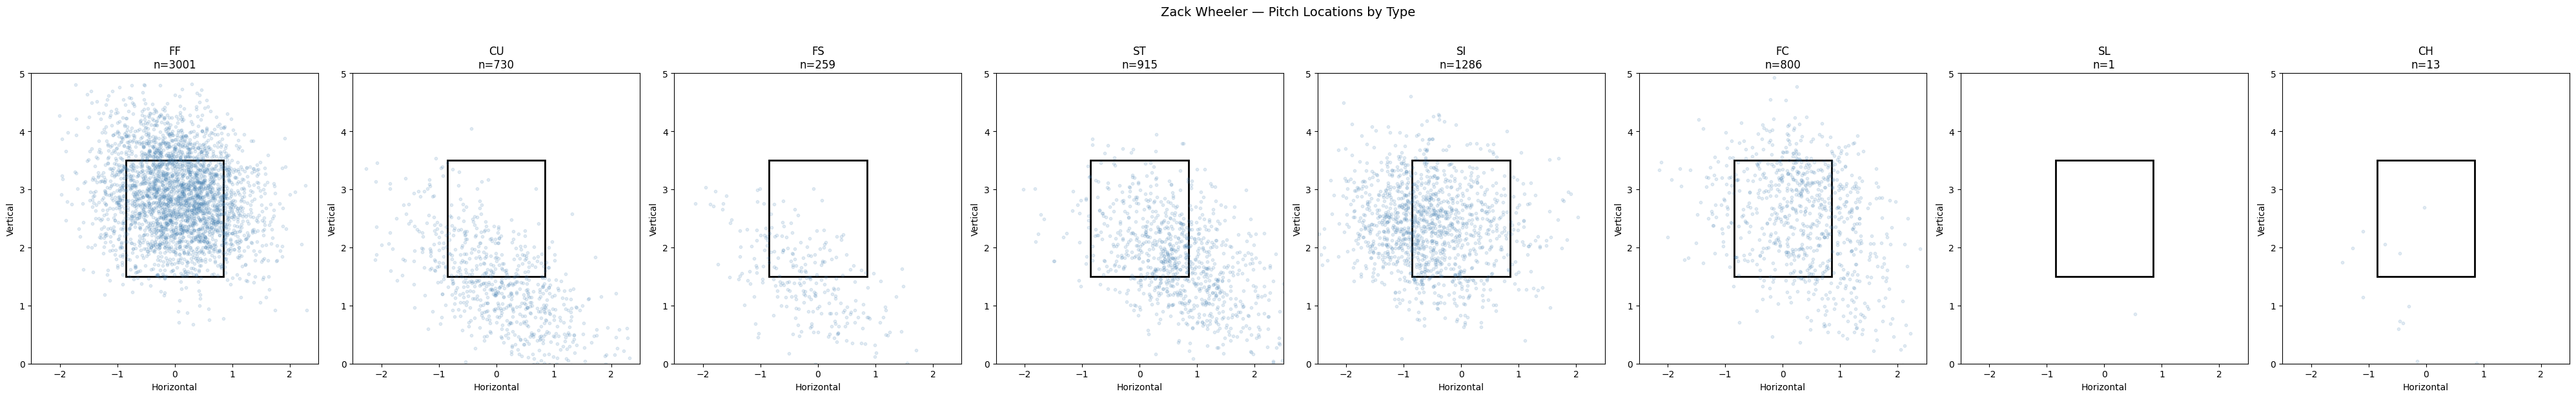

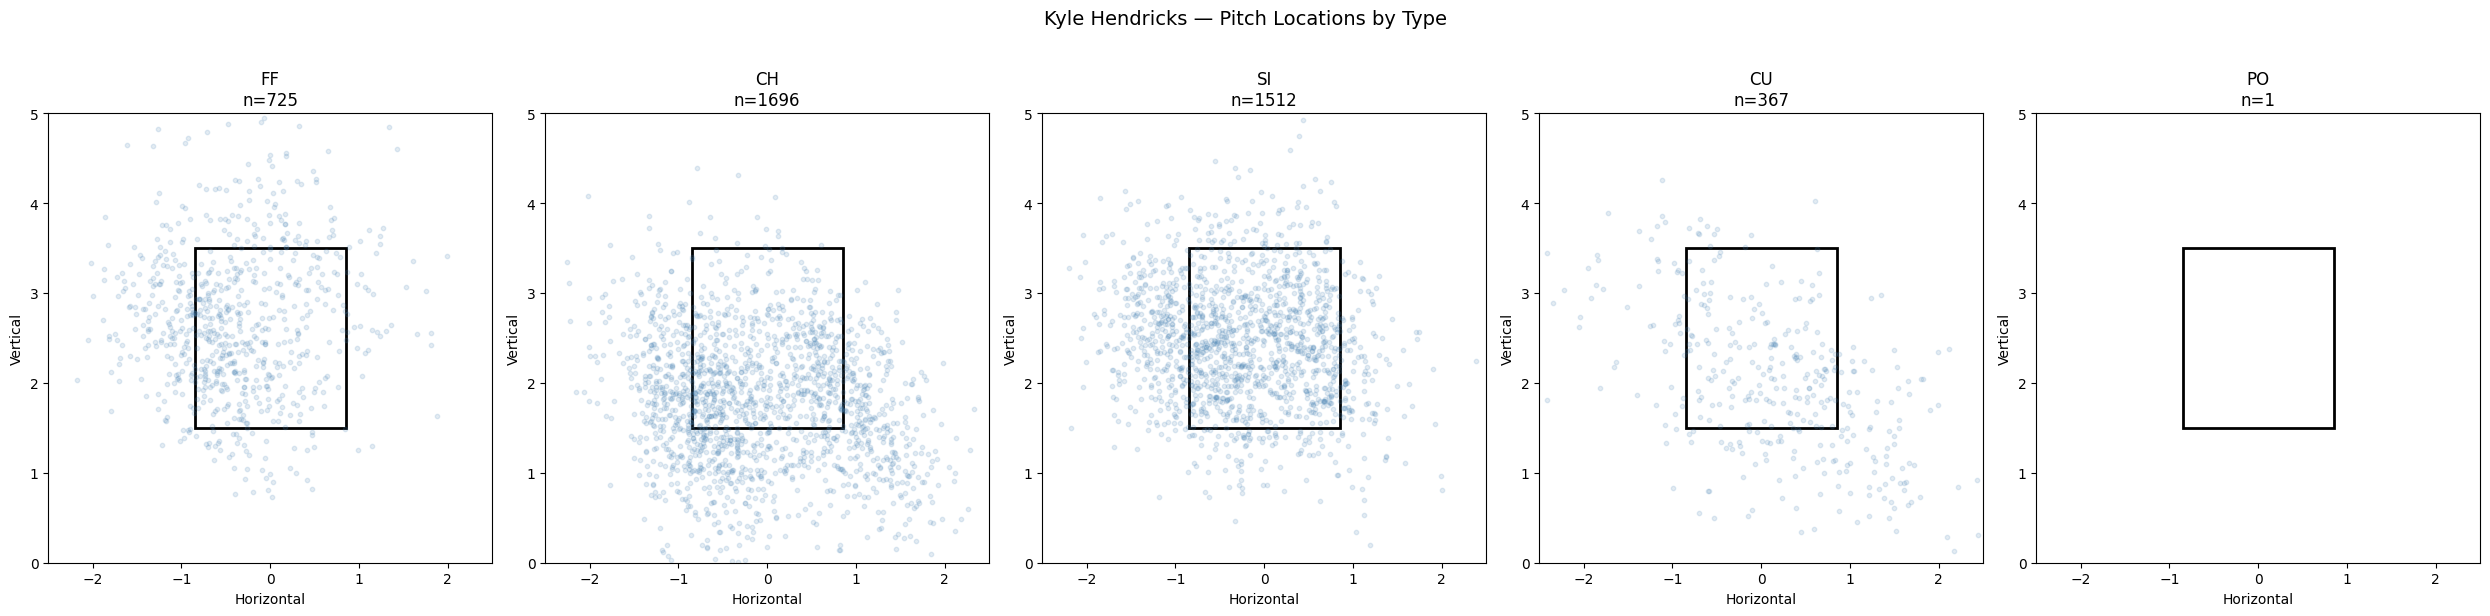

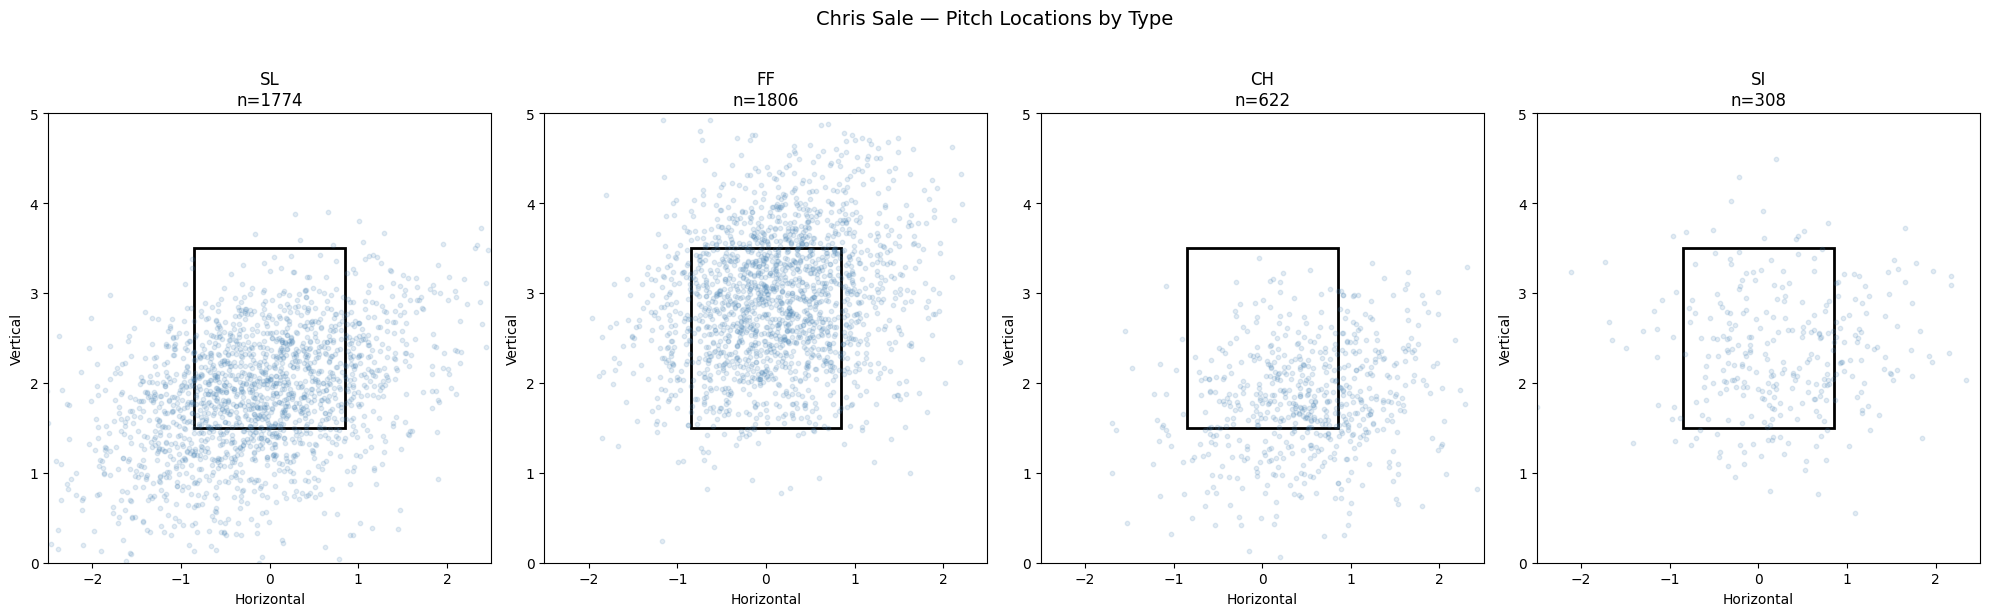

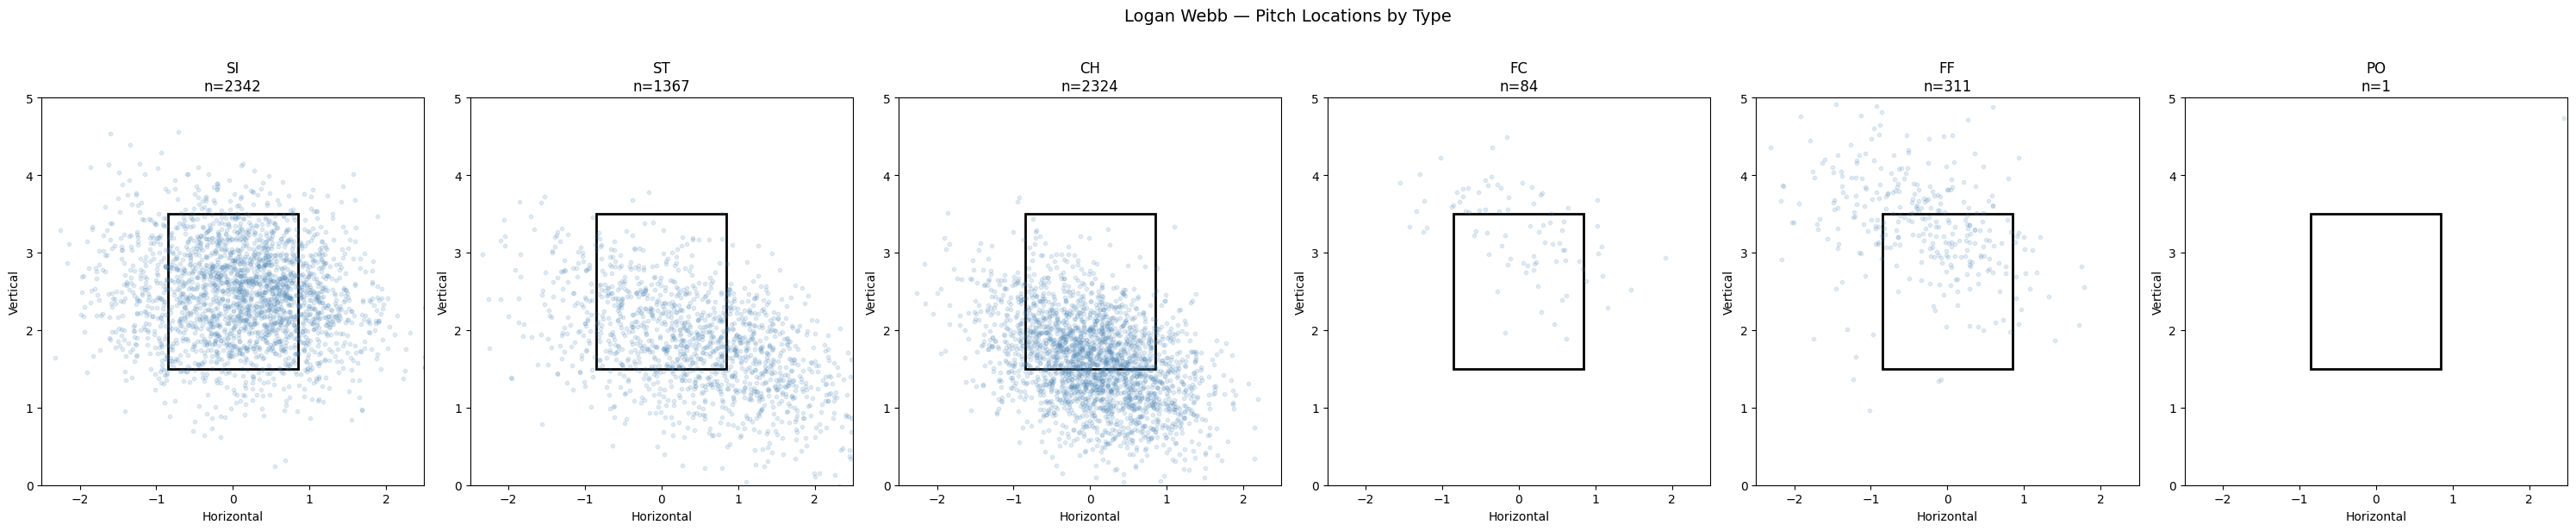

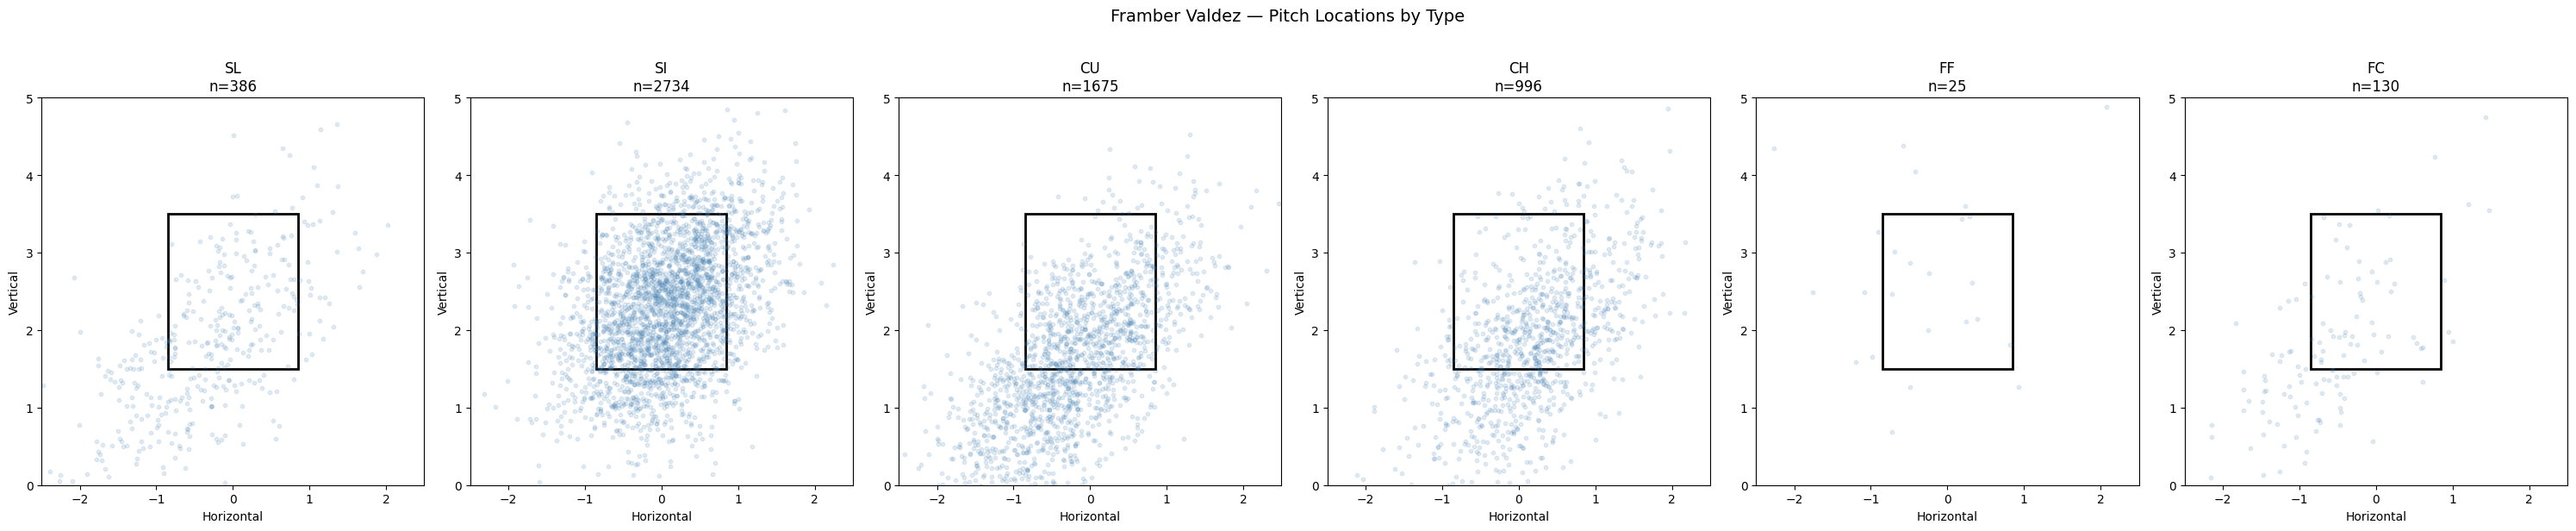

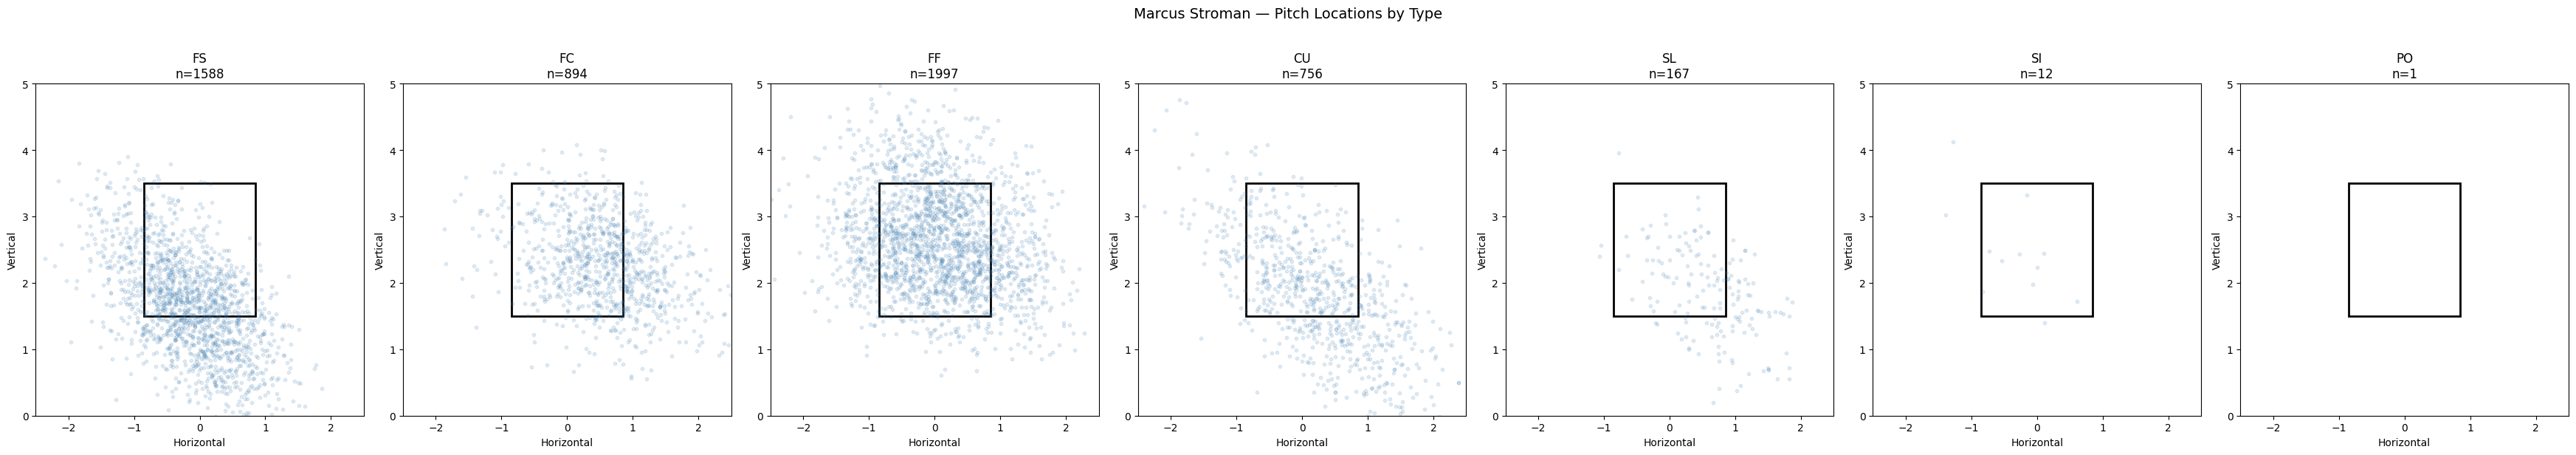

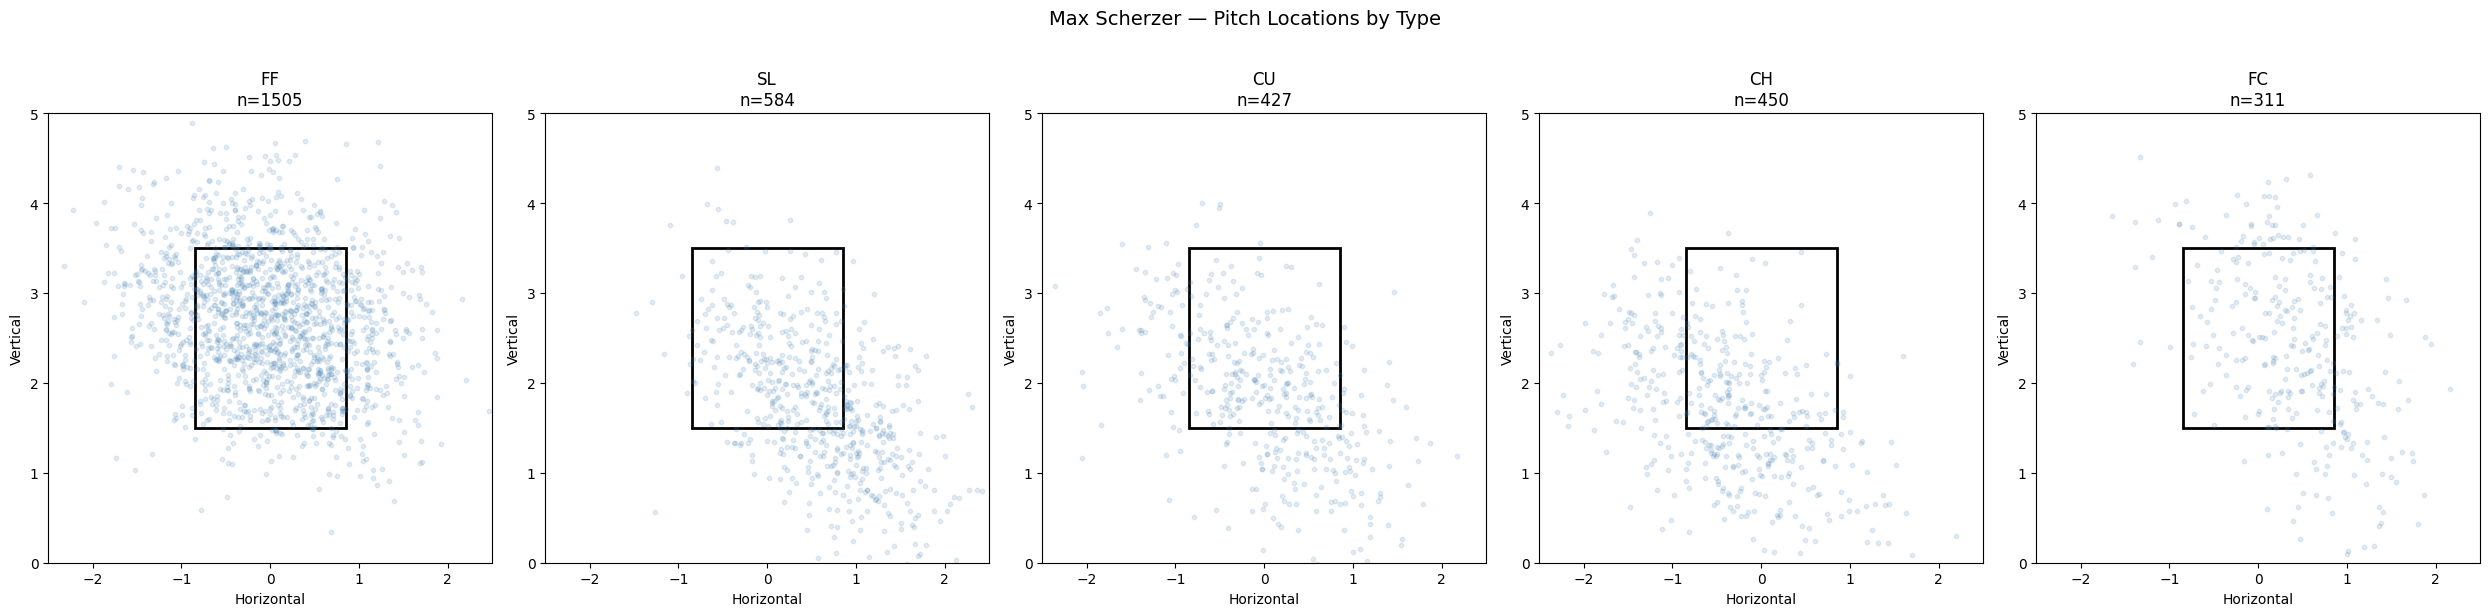

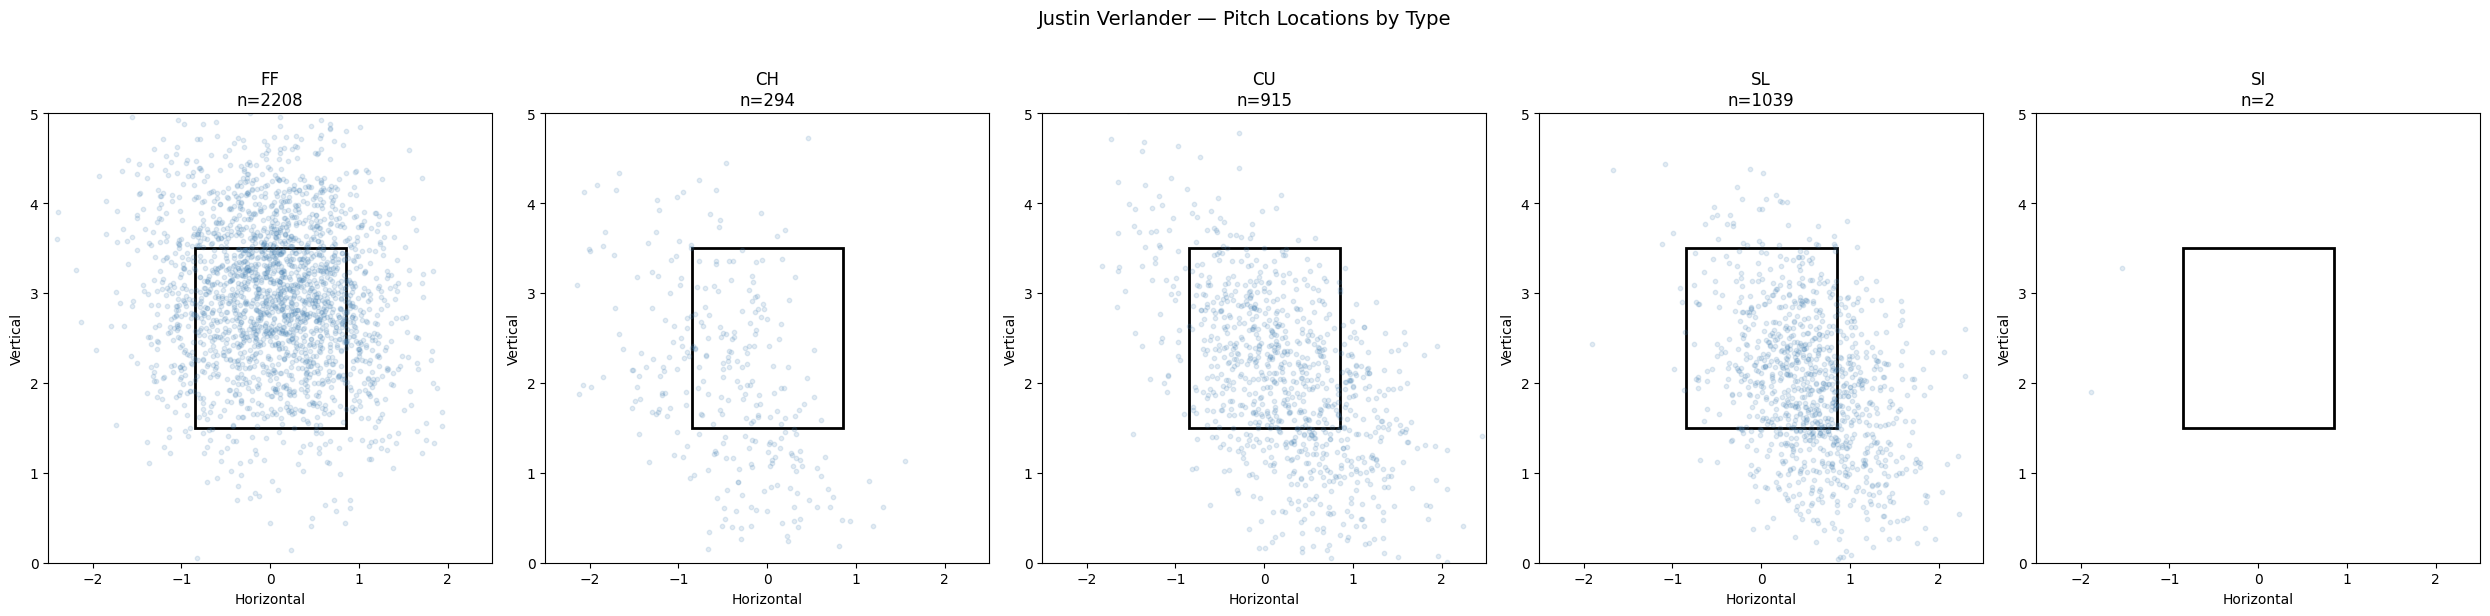

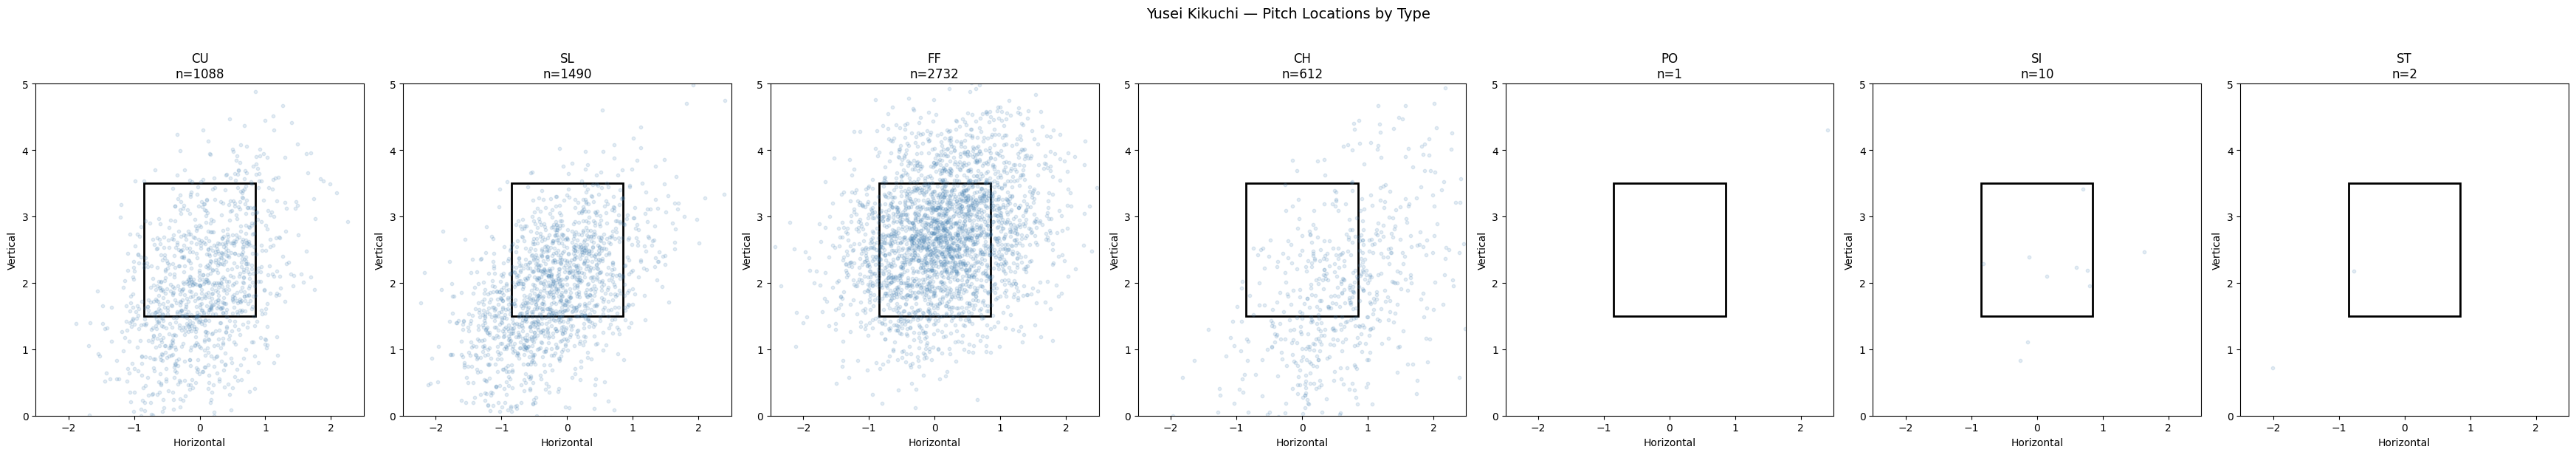

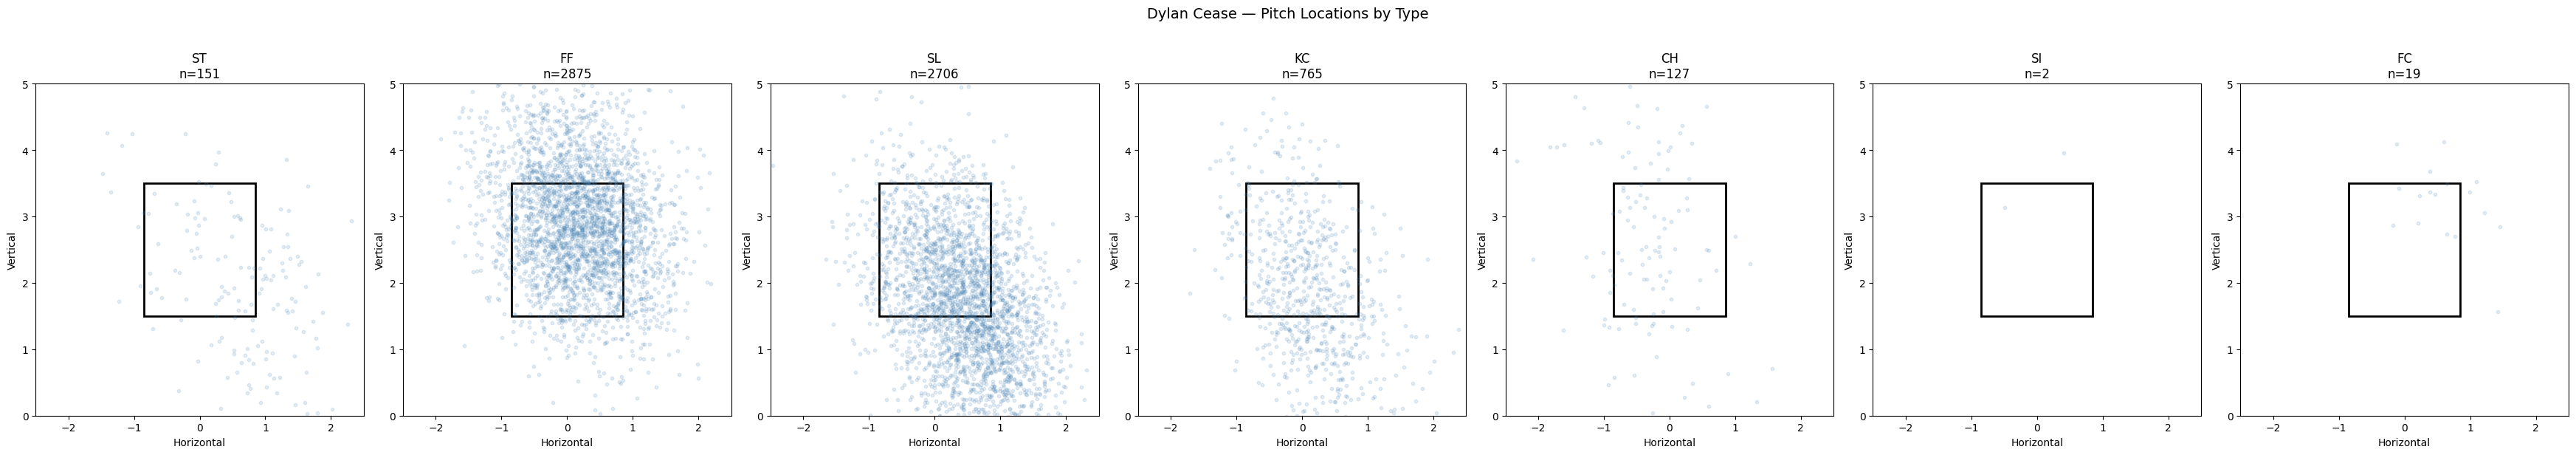

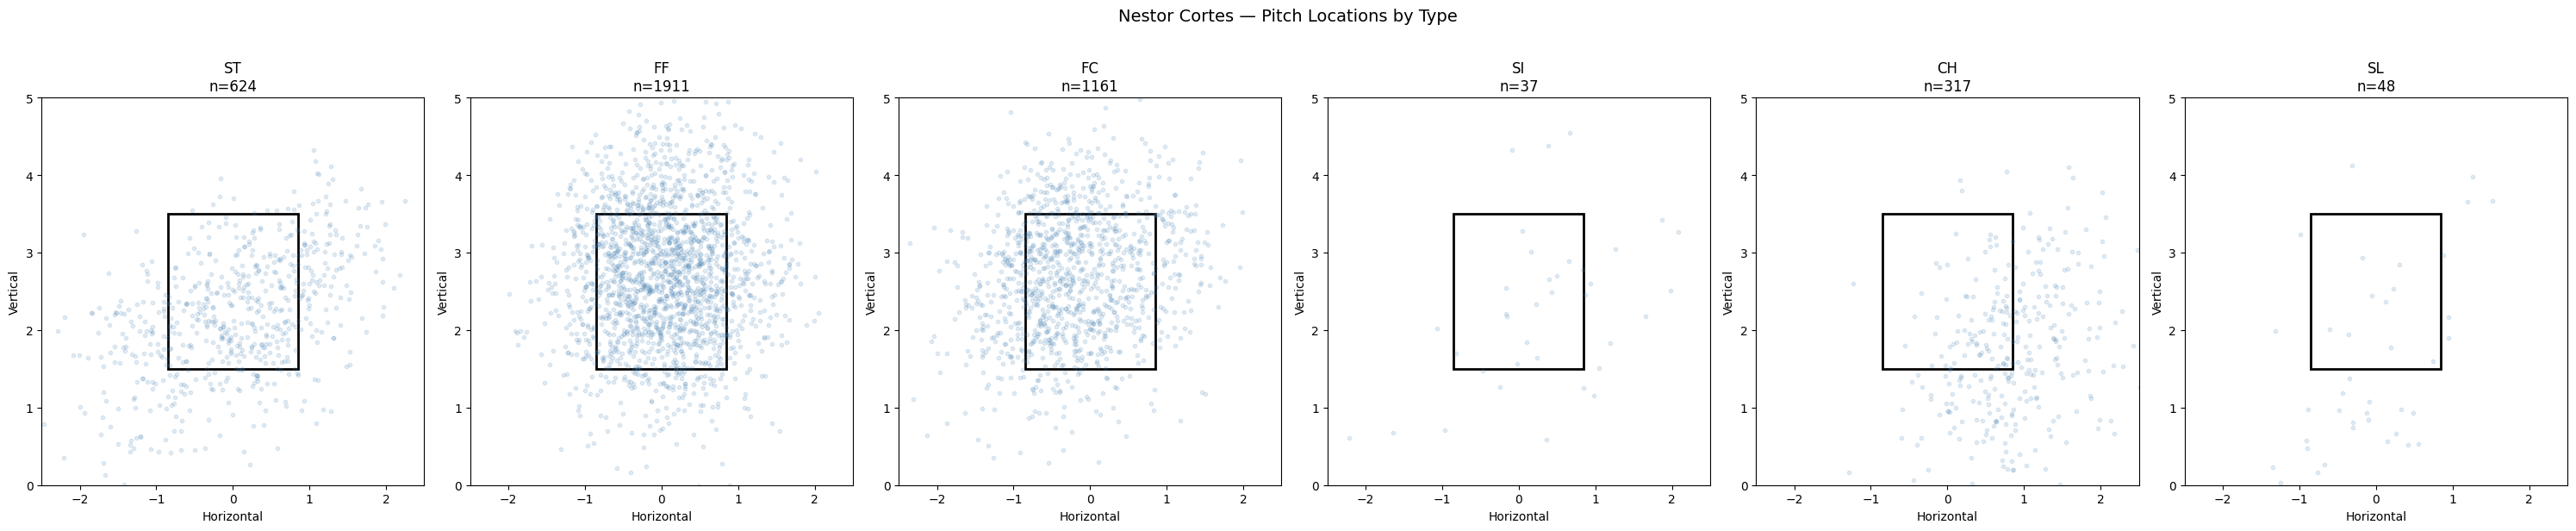

In [1]:
# notebooks/03_exploratory_analysis.ipynb

import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
from pitch_analysis import (load_data, get_pitcher, pitch_usage_by_count,
                             pitch_usage_by_handedness, plot_pitch_locations,
                             plot_usage_comparison)

# Load combined dataset
data = load_data()

# 1. League average pitch usage by count
# This becomes your baseline theory foundation
league_avg = pitch_usage_by_count(data)

# 2. Each pitcher vs league average
# Start seeing who deviates immediately
for name in data['pitcher_name'].unique():
    pitcher = get_pitcher(data, name)
    usage = pitch_usage_by_count(pitcher)
    print(f"\n{name}")
    print(usage.pivot(index='count', columns='pitch_type', values='pct')
               .fillna(0).round(1))

# 3. Side by side comparisons
# Cole (conventional) vs Cease (extreme slider usage)
plot_usage_comparison(data, 'Gerrit Cole', 'Dylan Cease')

# 4. Location analysis for each pitcher
for name in data['pitcher_name'].unique():
    pitcher = get_pitcher(data, name)
    plot_pitch_locations(pitcher, name)